In [1]:
import os, tarfile, urllib.request, json, math, copy, time, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.transforms.functional import InterpolationMode
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm

from linear_attention import ReLULinearSelfAttention, replace_vit_self_attention_with_linear

In [2]:
# -------------------
# Knobs
# -------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_VAL   = 64
NUM_WORKERS = 2

# Training regime
EPOCHS = 15
WARMUP_PCT = 0.05
LABEL_SMOOTH = 0.1
WD = 0.05
LR_HEAD = 3e-4               # classifier head LR
LR_BODY = 3e-5               # encoder LR (when unfrozen)

# Finetune modes
FULL_FINETUNE   = True      # set True to unfreeze entire model
UNFREEZE_LAST_K = 3          # used only when FULL_FINETUNE == False

CLIP_NORM = 1.0
USE_AMP = (DEVICE == "cuda")

In [3]:
from transformers import (
    AutoImageProcessor, ViTForImageClassification,
    get_cosine_schedule_with_warmup
)

torch.manual_seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# -------------------
# 0) Download Imagenette-320
# -------------------
DATA_ROOT = "./dataset/"
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
ARCHIVE_PATH = os.path.join(DATA_ROOT, "imagenette2-320.tgz")
EXTRACT_DIR  = os.path.join(DATA_ROOT, "imagenette2-320")
TRAIN_DIR    = os.path.join(EXTRACT_DIR, "train")
VAL_DIR      = os.path.join(EXTRACT_DIR, "val")

os.makedirs(DATA_ROOT, exist_ok=True)
if not os.path.isdir(EXTRACT_DIR):
    print("Downloading Imagenette-320...")
    urllib.request.urlretrieve(IMAGENETTE_URL, ARCHIVE_PATH)
    print("Extracting...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as t:
        t.extractall(DATA_ROOT)
    print("Ready:", TRAIN_DIR, VAL_DIR)
else:
    print(f"Dataset Exists...")

Dataset Exists...


In [5]:
# -------------------
# 1) Load base model + processor
# -------------------
MODEL_NAME = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast=True)
baseline  = ViTForImageClassification.from_pretrained(MODEL_NAME, output_attentions=False).to(DEVICE).eval()

In [6]:
# -------------------
# 2) ReLU-Linear Self-Attention block
# -------------------


# Make our trainable copy and swap attention
linear = copy.deepcopy(baseline)
replace_vit_self_attention_with_linear(linear)
linear.to(DEVICE)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ReLULinearSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in

In [7]:
# -------------------
# 3) Datasets & Loaders
# -------------------
short_edge = processor.size.get("shortest_edge", 256)
target = processor.size.get("height", 224)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(target, scale=(0.8, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])
val_tf = transforms.Compose([
    transforms.Resize(short_edge, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(target),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

ds_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
ds_val   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE_TRAIN, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE_VAL,   shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

In [8]:
# -------------------
# 4) Swap classifier to 10 classes (Imagenette order)
# -------------------
num_feats = linear.config.hidden_size
num_classes = len(ds_train.classes)  # 10
linear.classifier = nn.Linear(num_feats, num_classes)
torch.nn.init.trunc_normal_(linear.classifier.weight, std=0.02)
nn.init.zeros_(linear.classifier.bias)

# Track class ↔ index in config (optional)
linear.config.num_labels = num_classes
linear.config.id2label = {i: c for i, c in enumerate(ds_train.classes)}
linear.config.label2id = {c: i for i, c in enumerate(ds_train.classes)}

linear.to(DEVICE)  # IMPORTANT: move new classifier to DEVICE

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ReLULinearSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in

In [9]:
# -------------------
# 5) Freeze/unfreeze helper
# -------------------
def configure_trainable(model, full_finetune=False, last_k=3):
    # Freeze everything
    for p in model.parameters():
        p.requires_grad = False

    if full_finetune:
        # Unfreeze all encoder blocks
        for p in model.vit.parameters():
            p.requires_grad = True
    else:
        # Unfreeze last K transformer blocks
        enc = model.vit.encoder.layer
        k = min(last_k, len(enc))
        for blk in enc[-k:]:
            for p in blk.parameters():
                p.requires_grad = True

    # Always unfreeze final LayerNorm and classifier head
    for p in model.vit.layernorm.parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True

# Choose your mode here:
configure_trainable(linear, full_finetune=FULL_FINETUNE, last_k=UNFREEZE_LAST_K)

In [10]:
# -------------------
# 6) Optimizer, loss, schedule
# -------------------
def param_groups(model):
    groups = []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        lr = LR_HEAD if n.startswith("classifier") else LR_BODY
        wd = 0.0 if p.ndim == 1 else WD
        groups.append({"params": [p], "lr": lr, "weight_decay": wd})
    return groups

optimizer = torch.optim.AdamW(param_groups(linear), betas=(0.9, 0.999), eps=1e-8)
total_steps = EPOCHS * len(dl_train)
warmup_steps = max(1, int(WARMUP_PCT * total_steps))
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps,
                                            num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

In [11]:
# -------------------
# 7) Eval helpers
# -------------------
@torch.no_grad()
def eval_top1_linear10(model, loader):
    """Evaluate the 10-class head (our linear-attn model)."""
    model.eval()
    correct, seen = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(pixel_values=imgs).logits
        pred = logits.argmax(-1)
        correct += (pred == labels).sum().item()
        seen += labels.numel()
    return correct / max(seen, 1)

# Baseline 1k→Imagenette-10 mapping
IMAGENET_CLASS_INDEX_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with urllib.request.urlopen(IMAGENET_CLASS_INDEX_URL) as f:
    cls_index = json.load(f)  # str(int)->[wnid, human]
MODEL_ID2WNID = {}
for k, v in baseline.config.id2label.items():
    idx = int(k)
    name = str(v)
    first = name.split()[0]
    if len(first) == 9 and first.startswith("n") and first[1:].isdigit():
        MODEL_ID2WNID[idx] = first
    else:
        MODEL_ID2WNID[idx] = cls_index[str(idx)][0]

LOCAL_IDX2WNID = {i: wnid for i, wnid in enumerate(ds_val.classes)}
WNID2LOCAL = {wnid: i for i, wnid in LOCAL_IDX2WNID.items()}
MODEL_ID2LOCAL = {mid: WNID2LOCAL.get(wnid, -1) for mid, wnid in MODEL_ID2WNID.items()}
SUBSET_IDX = torch.tensor([mid for mid, li in MODEL_ID2LOCAL.items() if li != -1], dtype=torch.long, device=DEVICE)
MID2LOCAL_T = torch.tensor([MODEL_ID2LOCAL[mid] for mid in SUBSET_IDX.tolist()], dtype=torch.long, device=DEVICE)

@torch.no_grad()
def eval_top1_baseline_subset10(model, loader):
    """Evaluate baseline by masking logits to Imagenette's 10 classes."""
    model.eval()
    correct, seen = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(pixel_values=imgs).logits  # (B,1000)
            logits_sub = logits.index_select(dim=1, index=SUBSET_IDX)  # (B,10)
        pred_local = MID2LOCAL_T[logits_sub.argmax(-1)]
        correct += (pred_local == labels).sum().item()
        seen += labels.numel()
    return correct / max(seen, 1)

# Quick sanity before training
print("Sanity (val, linear model before FT):", f"{eval_top1_linear10(linear, dl_val)*100:.2f}%")
BASELINE_VAL = eval_top1_baseline_subset10(baseline, dl_val)
print("Baseline (val, subset-10)           :", f"{BASELINE_VAL*100:.2f}%")

Sanity (val, linear model before FT): 10.37%
Baseline (val, subset-10)           : 99.72%


In [12]:
# -------------------
# 8) Train loop (save best) + per-epoch logs
# -------------------
SAVE_DIR = "./vit_linear_relu_finetuned"
os.makedirs(SAVE_DIR, exist_ok=True)
best_acc = -1.0
best_path = os.path.join(SAVE_DIR, "best_linear_relu.pt")

hist = {"epoch": [], "train_loss": [], "val_acc_linear": [], "val_acc_baseline": []}

for epoch in range(1, EPOCHS+1):
    linear.train()
    running = 0.0
    t0 = time.time()
    for imgs, labels in dl_train:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = linear(pixel_values=imgs).logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(linear.parameters(), CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += loss.item()

    val_acc = eval_top1_linear10(linear, dl_val)
    epoch_time = time.time()-t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {running/len(dl_train):.4f} | val@1 {val_acc*100:.2f}% | {epoch_time:.1f}s")

    # Save best
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"state_dict": linear.state_dict(),
                    "config": linear.config.to_dict(),
                    "classes": ds_train.classes},
                   best_path)
        print(f"  ↳ New best! Saved to {best_path}")

    # Log history
    hist["epoch"].append(epoch)
    hist["train_loss"].append(running/len(dl_train))
    hist["val_acc_linear"].append(val_acc)
    hist["val_acc_baseline"].append(BASELINE_VAL)  # constant line

print(f"\nBest val@1 (linear): {best_acc*100:.2f}%")

Epoch 01/15 | loss 1.5052 | val@1 81.35% | 34.1s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 02/15 | loss 0.8509 | val@1 85.25% | 34.2s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 03/15 | loss 0.7036 | val@1 88.87% | 34.3s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 04/15 | loss 0.6232 | val@1 88.05% | 34.1s
Epoch 05/15 | loss 0.5777 | val@1 89.89% | 34.2s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 06/15 | loss 0.5497 | val@1 90.29% | 34.2s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 07/15 | loss 0.5323 | val@1 90.62% | 34.1s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 08/15 | loss 0.5223 | val@1 90.73% | 33.9s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear_relu.pt
Epoch 09/15 | loss 0.5155 | val@1 91.01% | 33.8s
  ↳ New best! Saved to ./vit_linear_relu_finetuned/best_linear

In [13]:
# -------------------
# 9) Load best and export TorchScript
# -------------------
ckpt = torch.load(best_path, map_location=DEVICE)
linear.load_state_dict(ckpt["state_dict"])
linear.to(DEVICE)

class ViTCLSWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, pixel_values: torch.Tensor):
        return self.m(pixel_values=pixel_values).logits

ts = ViTCLSWrapper(linear).eval().to(DEVICE)
example = torch.randn(1, 3, 224, 224, device=DEVICE)
scripted = torch.jit.trace(ts, (example,))
scripted.save(os.path.join(SAVE_DIR, "model_ts.pt"))
print("Saved TorchScript to:", os.path.join(SAVE_DIR, "model_ts.pt"))

/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/modeling_utils.py:4713: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/models/vit/modeling_vit.py:163: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if num_channels != self.num_channels:
/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/models/vit/modeling_vit.py:169: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future

Saved TorchScript to: ./vit_linear_relu_finetuned/model_ts.pt


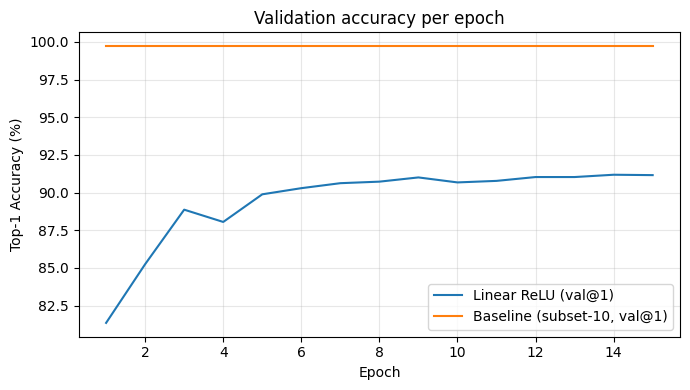

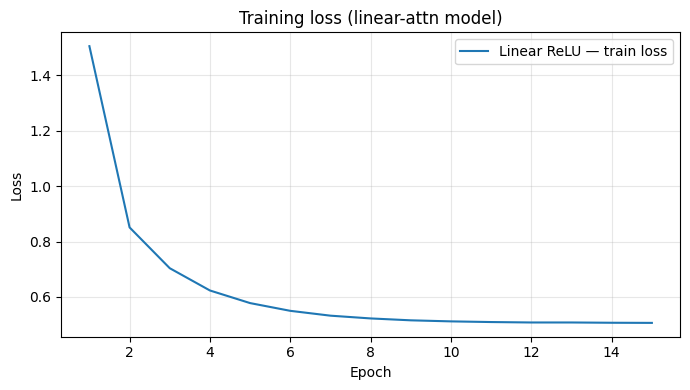

In [14]:
# -------------------
# 10) Plots
# -------------------
epochs = hist["epoch"]
plt.figure(figsize=(7,4))
plt.plot(epochs, [a*100 for a in hist["val_acc_linear"]], label="Linear ReLU (val@1)")
plt.plot(epochs, [a*100 for a in hist["val_acc_baseline"]], label="Baseline (subset-10, val@1)")
plt.xlabel("Epoch"); plt.ylabel("Top-1 Accuracy (%)")
plt.title("Validation accuracy per epoch")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, hist["train_loss"], label="Linear ReLU — train loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training loss (linear-attn model)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()